# Approximation in Hilbert spaces, SVM, Tikhonov Regularization

## Block 1 (45 min) — Theory  


### 1. Hilbert spaces

**Motivation:**
1. In machine learning, we often want to represent complex objects (audio signals, images, sequences, distributions) in a way that allows linear methods to work effectively.
2. *Feature maps & kernels:* Many nonlinear ML algorithms (SVMs, kernel ridge regression, Gaussian processes) can be seen as linear algorithms in a high- or infinite-dimensional Hilbert space $\mathcal{H}$.
   - Implicitly, via the **kernel trick**, we work in $\mathcal{H}$ without ever constructing the features.
   - Example: Gaussian kernel corresponds to an infinite-dimensional space of smooth functions.
3. Regression, classification, and signal reconstruction often require approximating functions in $L^2$ or other function spaces.
   - Fourier series, wavelets, and RKHS expansions are all examples of representing elements in infinite-dimensional Hilbert spaces.

A **scalar product** (inner product) on a (possible infinite dimensional) real or complex vector space $X$ is a function
$$
\langle x, y \rangle : X \times X \to \mathbb{R} \text{ or } \mathbb{C}
$$
satisfying:

1. **Linearity:** $\langle ax + by, z \rangle = a \langle x, z \rangle + b \langle y, z \rangle$  
2. **Symmetry:** $\langle x, y \rangle = \overline{\langle y, x \rangle}$  
3. **Positivity:** $\langle x, x \rangle \ge 0$, equality iff $x = 0$  

- **Induced norm:** $\|x\| = \sqrt{\langle x, x \rangle}$  
- **Pre-Hilbert space:** inner product space  
- **Hilbert space:** complete pre-Hilbert space  

**ML examples:**  
- $\mathbb{R}^n$: feature vectors, embeddings  
- $L^2([a,b])$: signals, wavelets  
- $\ell^2$: sequence or time-series data  

**Theorem:** Let $X$ be an inner product space and let $\{e_n\}$ be an orthonormal set in $X$. Then for any $x \in X$ and $n \in \mathbb{N} $,  
$$
\| x - \sum_{k=1}^{n} \alpha_k e_k \|^2 \geq \| x \|^2 - \sum_{k=1}^{n} |\langle x, e_k \rangle|^2
$$  
for any scalars $\alpha_1, \dots, \alpha_n \in \mathbb{C}$. 
- Equality holds if and only if $\alpha_k = \langle x, e_k \rangle$ for $k = 1, \dots, n$.  
- Furthermore, for any $x \in X$,  
  $$
  \sum_{n} |\langle x, e_n \rangle|^2 \leq \|x\|^2 \quad \text{(Bessel's inequality)}.
  $$

**Cauchy-Schwarz inequality:** In any inner product space, the following inequality holds for all $x, y \in X$:
$$
|\langle x, y \rangle| \leq \|x\| \, \|y\|.
$$


#### Gram-Schmidt Orthogonalization

Let $\{x_n\}_{n=1}^{\infty}$ be a linearly independent set in an inner product space $H$.

The process is defined recursively by setting $e_1 = \frac{x_1}{\|x_1\|}$ and then, for $n \geq 2$,
$$
u_n = x_n - \sum_{k=1}^{n-1} \langle x_n, e_k \rangle e_k, \quad e_n = \frac{u_n}{\|u_n\|}.
$$

- This algorithm produces an orthonormal set $\{e_n\}_{n=1}^\infty$
- each $e_n$ is a linear combination of $x_1, \ldots, x_n$,
- $$
  \text{span}\{x_1, \ldots, x_n\} = \text{span}\{e_1, \ldots, e_n\} \quad \text{for all } n.
  $$
  

#### Abstract Fourier Series

**Completeness of orthonormal systems:** We say that the orthonormal system $\{e_n\}$ is *complete* in $X$ if the only vector orthogonal to every $e_n$ is the zero vector, i.e., if $\langle x, e_n \rangle = 0$ for all $n$ implies $x = 0$. 

Let $\{e_n\}$ be a complete orthonormal set in a Hilbert space $X$. 
- For any $x \in X$, the **abstract Fourier series** of $x$ with respect to $\{e_n\}$ is given by
  $$
    x\sim \sum_{n=0}^\infty \langle x, e_n \rangle e_n.
  $$
- The scalars $\langle x, e_n \rangle$ are called the *Fourier coefficients* of $x$ with respect to $\{e_n\}$.

**Theorem:** The following are equivalent:

1. For every $x\in H$,	$
\sum_{n=0}^N \langle x, e_n \rangle e_n \to x,\,\,N\to\infty.
$
    
2. For every $x,y\in H$,
	$
	\langle x, y\rangle = \sum_{n=0}^{\infty} \langle x, e_n\rangle \overline{\langle y, e_n\rangle}.
	$
	
3. For every $x\in H$,
	$
	\|x\|^2 = \sum_{n=0}^\infty |\langle x, e_n \rangle|^2,\,\,\text{(Parseval identity)}.
	$ 
	
4. The system $\{e_n\}_{n\in\mathbb{N}}$ is complete.

#### Best Approximation from a Convex Set

**Theorem:** Let $K$ be a non-empty, convex and closed subset of the Hilbert space $H$. Then, for every $x \in H$, there exists a unique $y \in K$ such that  
$$
\|y - x\| = d(x, K) := \inf_{z \in K} \|z - x\|.
$$  
Furthermore, if $(y_n)_{n \in \mathbb{N}}$ is a sequence in $K$ such that $\|y_n - x\| \to d(x, K)$ as $n \to \infty$, then $y_n \to y$ as $n \to \infty$.

---

	
### 2. Support Vector Machines (SVMs) -- Linear version

In many machine learning problems, the goal is to predict one of a small number of discrete outcomes.
In **binary classification**, the labels take values in $y \in \{-1, +1\}$.

We are given a training dataset
$$
(x_1, y_1), \dots, (x_n, y_n),
\quad x_i \in \mathbb{R}^p,\; y_i \in \{-1, +1\}.
$$

The task is to learn a classifier that separates the two classes.

A linear classifier is defined by a hyperplane
$$
\langle w, x \rangle - b = 0,
$$
where $w \in \mathbb{R}^p$ is the normal vector and $b \in \mathbb{R}$ is the bias.

The resulting classifier is
$$
x \mapsto \operatorname{sign}(\langle w, x \rangle - b).
$$

#### Margin and Maximum-Margin Principle

If the data are **linearly separable**, there exist infinitely many separating hyperplanes.
The Support Vector Machine selects the one with the **largest margin**.

We define two parallel hyperplanes:
$$
\langle w, x \rangle - b = 1,
\qquad
\langle w, x \rangle - b = -1.
$$

The distance between them is
$
\frac{2}{\|w\|}.
$

Maximizing this distance is equivalent to minimizing $\|w\|$.


The maximum-margin classifier is obtained by solving:
$$
\begin{aligned}
\min_{w,b} \quad & \frac{1}{2}\|w\|^2 \\
\text{subject to} \quad & y_i(\langle w, x_i \rangle - b) \ge 1,
\quad i=1,\dots,n.
\end{aligned}
$$

This is a convex quadratic optimization problem.


Only data points that satisfy
$$
y_i(\langle w, x_i \rangle - b) = 1
$$
affect the solution.

These points are called **support vectors**.
All other points are irrelevant once the optimal hyperplane is found.

#### Soft-Margin SVM and Hinge Loss

When the data are not perfectly separable, we allow violations of the margin.

The **hinge loss** is defined as
$$
\ell_{\text{hinge}}(y, f(x)) = \max\{0,\,1 - y f(x)\},
\quad f(x) = \langle w, x \rangle - b.
$$

- Loss is zero if the point is correctly classified with margin.
- Loss grows linearly when the margin constraint is violated.

The soft-margin SVM solves:
$$
\min_{w,b}
\;\|w\|^2
+ C \frac{1}{n}\sum_{i=1}^n
\max\{0,\,1 - y_i(\langle w, x_i \rangle - b)\},
$$
where $C > 0$ controls the trade-off between margin size and classification errors.

Equivalently, by introducing slack variables, the problem can be written as:
$$
\begin{aligned}
\min_{w,b,\zeta} \quad & \|w\|^2 + C\sum_{i=1}^n \zeta_i \\
\text{subject to} \quad &
y_i(\langle w, x_i \rangle - b) \ge 1 - \zeta_i, \\
& \zeta_i \ge 0, \quad i=1,\dots,n.
\end{aligned}
$$

#### Concluding Remarks

- Linear SVM learns a **maximum-margin linear classifier**.
- The solution depends only on a small subset of training points.
- This formulation prepares the ground for **kernel methods**, where the same optimization
is carried out in high- or infinite-dimensional Hilbert spaces.

---

### 3. Linear Ridge Regression


We are given training data $(x_1, y_1), \dots, (x_n, y_n)$, $x_i \in \mathbb{R}^p,\; y_i \in \mathbb{R}$.
We consider linear predictors
$$
f_w(x) = w^\top x,
\quad w \in \mathbb{R}^p.
$$

**Empirical Risk Minimization:** The squared loss is
$$
\ell(y, f_w(x)) = (y - w^\top x)^2.
$$

Ordinary least squares solves
$$
\min_{w \in \mathbb{R}^p}
\;\frac{1}{n}\sum_{i=1}^n (y_i - w^\top x_i)^2.
$$

This problem may be ill-posed when:
- $p \gg n$,
- features are highly correlated,
- the design matrix is nearly singular.


#### Ridge Regression (Tikhonov Regularization)
Ridge regression adds an $\ell_2$ penalty:
$$
\min_{w \in \mathbb{R}^p}
\;\frac{1}{n}\sum_{i=1}^n (y_i - w^\top x_i)^2
+ \lambda \|w\|_2^2,
\quad \lambda > 0.
$$

**Geometric interpretation:**
- We minimize squared error subject to a soft constraint on $\|w\|$.
- The solution is unique and stable.

**Closed-Form Solution:** Let $X \in \mathbb{R}^{n \times p}$ be the design matrix
and $y \in \mathbb{R}^n$ the response vector.

The solution satisfies
$$
(X^\top X + \lambda I)w = X^\top y,
$$
hence
$$
w^\star = (X^\top X + \lambda I)^{-1} X^\top y.
$$


**Spectral Viewpoint:** Let
$$
X^\top X = U \operatorname{diag}(\mu_1,\dots,\mu_p) U^\top,
\quad \mu_1 \ge \dots \ge \mu_p \ge 0.
$$

Then ridge rescales each eigendirection by
$$
\frac{\mu_j}{\mu_j + \lambda}.
$$

- Directions with small $\mu_j$ (ill-conditioned, noisy)
  are strongly damped.
- Directions with large $\mu_j$ are almost unchanged.


#### Maximum Likelihood Interpretation

Assume the linear model
$$
y_i = w^\top x_i + \varepsilon_i,
\quad \varepsilon_i \sim \mathcal{N}(0, \sigma^2),
$$
independently.

The negative log-likelihood is
$$
\frac{1}{2\sigma^2}
\sum_{i=1}^n (y_i - w^\top x_i)^2.
$$

Minimizing it yields **ordinary least squares**.


#### Bayesian Prior on the Weights

Assume a Gaussian prior: $w \sim \mathcal{N}(0, \tau^2 I)$. The negative log-prior is
$\frac{1}{2\tau^2}\|w\|_2^2$.

**MAP Estimation and Ridge Regression:** The negative log-posterior is
$$
\frac{1}{2\sigma^2}
\sum_{i=1}^n (y_i - w^\top x_i)^2
+
\frac{1}{2\tau^2}\|w\|_2^2.
$$

Multiplying by $2\sigma^2$, we obtain:
$$
\sum_{i=1}^n (y_i - w^\top x_i)^2
+
\lambda \|w\|_2^2,
\quad
\lambda = \frac{\sigma^2}{\tau^2}.
$$

**Interpretation of the Hyperparameter $\lambda$:**

- Large $\lambda$: strong prior belief that $w$ is small
  → simpler, more stable models.
- Small $\lambda$: data dominates the prior
  → closer to ordinary least squares.
- $\lambda$ balances **noise level** $(\sigma^2)$
  and **prior uncertainty** $(\tau^2)$.


#### Bias-Variance tradeoff:

- **Bias:**
  Ridge regression shrinks coefficients toward zero.
  This introduces bias:
  $$
  \mathbb{E}[\hat w_\lambda] \neq w^\ast.
  $$

- **Variance:**
  Regularization stabilizes the estimator:
  $$
  \operatorname{Var}(\hat w_\lambda)
  \;\downarrow\;
  \text{as } \lambda \uparrow.
  $$



## Block 2 (45 min) — Exercises

**Exercise 1** Let $H$ be a Hilbert space and $V \subset H$ a finite-dimensional subspace. Prove that the minimizer of  
   $\min_{v \in V} \|x - v\|$ is the orthogonal projection $P_V x$.

**Exercise 2** Let $H = L^2([0,1])$ and $e_k(t)=\sqrt{2}\sin(k\pi t)$.
    - Compute the first two Fourier coefficients of $x(t)=t$.
    - Write the best approximation of $x$ in $\mathrm{span}\{e_1,e_2\}$.
    - Bound the approximation error using Bessel’s inequality.

**Exercise 3** Given two linearly separable datasets in $\mathbb{R}^2$:
    - Draw two separating hyperplanes.
    - Identify which has the larger margin.
    - Compute the margin explicitly for a given $(w,b)$.

**Exercise 4** Consider three points:
$$
x_1=(1,0),\; y_1=1;\quad
x_2=(0,1),\; y_2=1;\quad
x_3=(-1,0),\; y_3=-1.
$$
- Write the hard-margin SVM optimization problem.
- Solve it explicitly.
- Identify the support vectors.

## Block 3 (45 min) — Programming

### 1. Wavelet Approximation in a Hilbert Space $L^2([0,1])$

This exercise illustrates best approximation in a Hilbert space using an
orthonormal wavelet basis. We study truncation, projection, and energy
concentration.

#### Background: What are Wavelets?

Wavelets provide an **orthonormal basis** of the Hilbert space  
$$
L^2([0,1]) = \left\{ f : [0,1]\to\mathbb{R} \;\middle|\; \int_0^1 |f(t)|^2\,dt < \infty \right\},
$$
similar to Fourier bases, but with a crucial difference:

- **Fourier basis:** global oscillations (sine/cosine), good for smooth, periodic signals  
- **Wavelet basis:** localized in *both time and scale*, good for signals with jumps or local features

Formally, a wavelet system is generated from a single function $\psi$ (the *mother wavelet*) by **scaling and translation**:
$$
\psi_{j,k}(t) = 2^{j/2}\,\psi(2^j t - k),
\quad j \in \mathbb{Z},\; k \in \mathbb{Z}.
$$

- $j$: scale (resolution level)
- $k$: location

If $\{\psi_{j,k}\}$ is orthonormal and complete, then every $f \in L^2([0,1])$ admits the expansion
$$
f = \sum_{j,k} \langle f, \psi_{j,k} \rangle \psi_{j,k},
\quad
\|f\|_{L^2}^2 = \sum_{j,k} |\langle f, \psi_{j,k} \rangle|^2
$$
(Parseval identity).


The **Haar wavelet** is the simplest wavelet. The mother wavelet is
$$
\psi(t) =
\begin{cases}
1, & 0 \le t < \tfrac{1}{2}, \\
-1, & \tfrac{1}{2} \le t < 1, \\
0, & \text{otherwise}.
\end{cases}
$$

From $\psi$, we generate $\psi_{j,k}(t) = 2^{j/2}\,\psi(2^j t - k)$, $j \ge 0$, $k = 0,\dots,2^j-1$.
- $\{\psi_{j,k}\}$ is an **orthonormal basis** of $L^2([0,1])$
- Compact support (perfect localization in time)
- Piecewise constant → ideal for functions with jumps
- Coefficients have a direct interpretation as *local differences*

For $f \in L^2([0,1])$,
$$
c_{j,k} = \langle f, \psi_{j,k} \rangle
$$
measures the **variation of \(f\)** on the interval $\left[\tfrac{k}{2^j}, \tfrac{k+1}{2^j}\right]$.
- Large $|c_{j,k}|$: significant local change at scale $2^{-j}$
- Small $|c_{j,k}|$: locally smooth behavior

This explains why wavelets outperform Fourier bases for non-smooth signals.

- Wavelet coefficients = inner products in $L^2$
- Truncation = approximation by a finite set of orthonormal vectors
- Energy identity:
$$
\|f\|_{L^2}^2 \approx \sum_{(j,k)\in\Lambda_N} |c_{j,k}|^2
+ \|f - \hat f_N\|_{L^2}^2
$$
(Bessel / Parseval)

**Task Description:**
1. Choose a non-smooth function $f$ (e.g. with a jump) in $H = L^2([0,1])$ to motivate wavelets.

2. Use the Haar wavelet basis $\{\psi_{j,k}\}$, and calculate wavelet coefficients up to order $N$.

3. Reconstruct the approximation $\hat{f}_N$.

4. Calculate the approximation error $\|f - \hat f_N\|_{L^2}$.  

5. Verify Bessel / Parseval numerically.

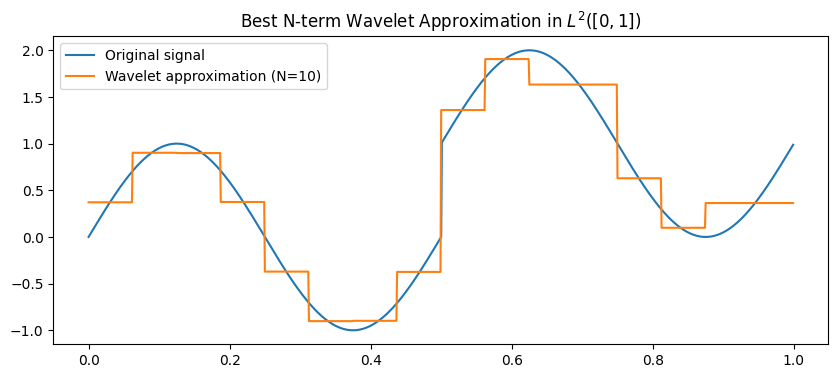

L2 approximation error: 0.2098806019335488
Signal energy: 0.9990234375
Wavelet coefficient energy: 0.9990234375000017


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Step 1: Define signal in L^2([0,1])
n = 1024
t = np.linspace(0, 1, n, endpoint=False)

# Piecewise smooth function with a jump
f = np.sin(4 * np.pi * t) + (t > 0.5)

# Step 2: Haar wavelet decomposition (orthonormal in L^2)
wavelet = "haar"
coeffs = pywt.wavedec(f, wavelet)

# Flatten coefficients and keep bookkeeping structure
coeff_arr, coeff_slices = pywt.coeffs_to_array(coeffs)

# Step 3: Best N-term approximation
N = 10  # number of kept coefficients
idx = np.argsort(np.abs(coeff_arr))[::-1]

coeff_arr_N = np.zeros_like(coeff_arr)
coeff_arr_N[idx[:N]] = coeff_arr[idx[:N]]

coeffs_N = pywt.array_to_coeffs(coeff_arr_N, coeff_slices, output_format="wavedec")
f_N = pywt.waverec(coeffs_N, wavelet)

# Step 4: Approximation error
error_L2 = np.linalg.norm(f - f_N) / np.sqrt(n)
energy_f = np.linalg.norm(f) ** 2 / n
energy_coeffs = np.sum(coeff_arr ** 2) / n

# Visualization
plt.figure(figsize=(10,4))
plt.plot(t, f, label="Original signal")
plt.plot(t, f_N, label=f"Wavelet approximation (N={N})")
plt.legend()
plt.title("Best N-term Wavelet Approximation in $L^2([0,1])$")
plt.show()

print("L2 approximation error:", error_L2)
print("Signal energy:", energy_f)
print("Wavelet coefficient energy:", energy_coeffs)

### 2. Linear SVM, Margin and the Role of $C$

This exercise illustrates the geometry of the linear SVM, the hinge loss,
and the effect of the regularization parameter $C$.

**Task Description:**

**Step 1: Generate a nearly linearly separable dataset**  
- Create a 2D binary classification dataset.
- Add mild overlap / noise so that perfect separation is not possible.

**Step 2: Train linear SVMs with different values of $C$**  
- Fit linear SVM classifiers for several values of \(C\).
- Observe how the margin and misclassification change.

**Step 3: Visualize decision boundary, margin, and support vectors**  
- Plot the separating hyperplane.
- Plot the margin boundaries.
- Highlight support vectors.

**Step 4: Interpretation**  
- Explain the behavior as $C \to 0$ and $C \to \infty$.
- Relate the observations to hinge loss and regularization.

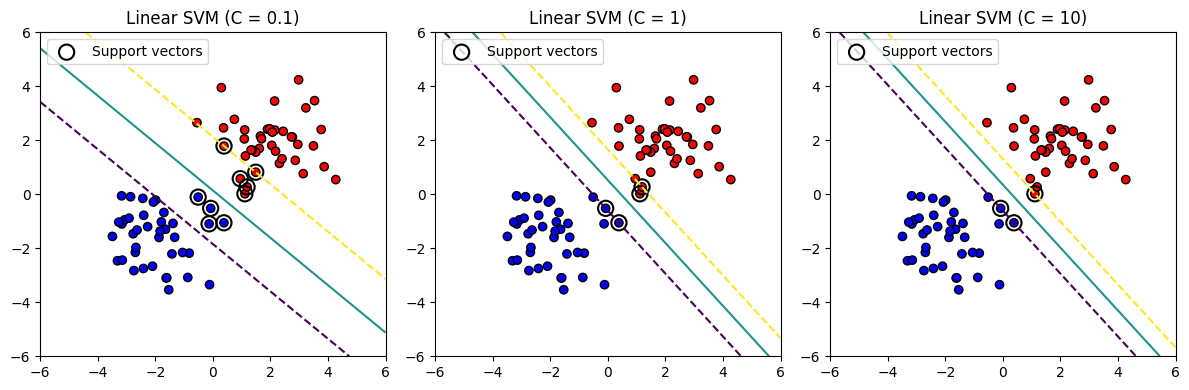

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Step 1: Generate data
np.random.seed(0)
n = 40

X_pos = np.random.randn(n, 2) + np.array([2, 2])
X_neg = np.random.randn(n, 2) + np.array([-2, -2])

X = np.vstack([X_pos, X_neg])
y = np.hstack([np.ones(n), -np.ones(n)])

# Step 2: Train SVMs with different C
Cs = [0.1, 1, 10]
models = [SVC(kernel="linear", C=C) for C in Cs]

for model in models:
    model.fit(X, y)

# Step 3: Visualization
xx = np.linspace(-6, 6, 200)
yy = np.linspace(-6, 6, 200)
XX, YY = np.meshgrid(xx, yy)
grid = np.c_[XX.ravel(), YY.ravel()]

plt.figure(figsize=(12, 4))

for i, (C, model) in enumerate(zip(Cs, models)):
    plt.subplot(1, 3, i + 1)

    Z = model.decision_function(grid)
    Z = Z.reshape(XX.shape)

    # Decision boundary and margins
    plt.contour(XX, YY, Z, levels=[-1, 0, 1], linestyles=["--", "-", "--"])
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=120,
        facecolors="none",
        edgecolors="k",
        linewidths=1.5,
        label="Support vectors"
    )

    plt.title(f"Linear SVM (C = {C})")
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.legend(loc="upper left")

plt.tight_layout()
plt.show()


### 3. Ridge Regression vs OLS on Ill-Conditioned Data

This exercise illustrates the effect of ill-conditioning in linear regression and how ridge (Tikhonov) regularization stabilizes the solution.


#### Task Description

**Step 1: Simulate ill-conditioned data**  
- Generate a design matrix $X \in \mathbb{R}^{n \times p}$ with rapidly decaying singular values to create ill-conditioning.  
- Generate a true coefficient vector $w_{\text{true}} \in \mathbb{R}^p$.  
- Generate observations $y = X w_{\text{true}} + \varepsilon$ with small Gaussian noise.

**Step 2: Compute regression solutions**  
- Compute the ordinary least squares (OLS) solution using the pseudo-inverse of $X$.  
- Compute ridge regression solutions for a range of regularization parameters $\lambda$:
$$
w_\lambda = (X^\top X + \lambda I)^{-1} X^\top y
$$

**Step 3: Visualize coefficient shrinkage in eigenbasis**  
- Compute the eigen-decomposition of $X^\top X = V \operatorname{diag}(\mu_i) V^\top$.  
- Project the true coefficients, OLS, and ridge solutions onto the eigenbasis: $w_{\text{eig}} = V^\top w$.  
- Plot the coefficients along eigenvectors to observe how ridge shrinks directions corresponding to small eigenvalues.



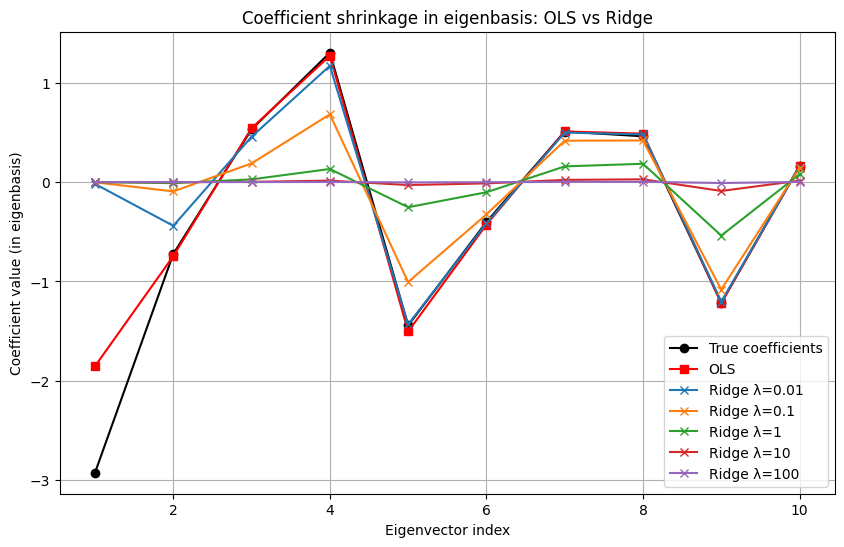

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Simulate ill-conditioned data
np.random.seed(42)
n, p = 50, 10

# Generate orthonormal matrices U and V
U, _ = np.linalg.qr(np.random.randn(n, p))
V, _ = np.linalg.qr(np.random.randn(p, p))

# Decaying singular values (ill-conditioned)
singular_values = np.linspace(1, 0.01, p)
X = U @ np.diag(singular_values) @ V.T

# True coefficients and observations
w_true = np.random.randn(p)
y = X @ w_true + 0.01 * np.random.randn(n)  # small noise

# Step 2: Compute OLS and Ridge solutions
w_ols = np.linalg.pinv(X) @ y

lambdas = [0.01, 0.1, 1, 10, 100]
w_ridge = [np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ y) for lam in lambdas]

# Step 3: Visualize shrinkage in eigenbasis
eigvals, eigvecs = np.linalg.eigh(X.T @ X)
w_true_eig = eigvecs.T @ w_true
w_ols_eig = eigvecs.T @ w_ols
w_ridge_eig = [eigvecs.T @ w for w in w_ridge]

plt.figure(figsize=(10,6))
plt.plot(range(1,p+1), w_true_eig, 'k-o', label='True coefficients')
plt.plot(range(1,p+1), w_ols_eig, 'r-s', label='OLS')
for lam, w in zip(lambdas, w_ridge_eig):
    plt.plot(range(1,p+1), w, marker='x', label=f'Ridge λ={lam}')
plt.xlabel('Eigenvector index')
plt.ylabel('Coefficient value (in eigenbasis)')
plt.title('Coefficient shrinkage in eigenbasis: OLS vs Ridge')
plt.legend()
plt.grid(True)
plt.show()